Can we get more oscillations if we have random first guess or if we set risk averse risk neutral?

In [2]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']

#from model import *
import model as mod
import model
from utils import *

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

def plots_across_runs_and_feedback(feedback_values, expmnt_nums, gpt_model, memory, temperature):
    n = 2  # number of rows (positive and negative feedback)
    m = 3  # number of columns (three runs)

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(n, m, figure=fig)
    
    max_price_pos = 0
    min_price_pos = 100
    max_price_neg = 0
    min_price_neg = 100
    
    for feedback in feedback_values:
        for expmnt_num in expmnt_nums:
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            if feedback == "pos":
                max_price_pos = max(max_price_pos, df["predicted_price"].max(), df["actual_price"].max())
                min_price_pos = min(min_price_pos, df["predicted_price"].min(), df["actual_price"].min())
    
            if feedback == "neg":
                max_price_neg = max(max_price_neg, df["predicted_price"].max(), df["actual_price"].max())
                min_price_neg = min(min_price_neg, df["predicted_price"].min(), df["actual_price"].min())
    
    for i, feedback in enumerate(feedback_values):
        for j, expmnt_num in enumerate(expmnt_nums):
            ax = fig.add_subplot(gs[i, j])
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50wrandstart_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            # Plot actual and predicted prices over time_step
            ax.plot(df['time_step'], df['actual_price'], label='Actual Price', color="black", linewidth=3)
            for agent_id, group in df.groupby('agent_id'):
                ax.plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
            
            if j == 0:
                ax.set_ylabel('Price')
            if i == 1:
                ax.set_xlabel('Time Step')
            ax.set_title(f"Run: {j+1}")
            ax.axhline(60, linestyle="dashed", color="black", alpha=0.5)
            # if j == 2:
            #     ax.legend(bbox_to_anchor=[1.05, 1])
            if i == 0:
                ax.set_ylim(0, 100)
            if i == 1:
                ax.set_ylim(0, 100)
    
    plt.suptitle(f"Memory: {memory}; Temperature: {temperature}", fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    filename = f"../results/plots/{gpt_model}_memory_{memory}_temperature_{temperature}_alternative_layout_randstart.png"
    plt.savefig(filename, bbox_inches='tight')
    plt.show()


In [4]:
path_exp = '../results/experiments/'
openai.__version__

'1.9.0'

In [5]:
# set simulation parameters
seed = 0
np.random.seed(seed)
noise_mean = 0
noise_sd = 1/4
temperature = 1
memory = 3
instruction_type = 'original_30-50w'
n_agents = 6
n_steps = 50
gpt_model="gpt-3.5-turbo"

In [6]:
feedback='pos'
expmnt_num = 2

In [21]:
###### TODO edit save ranme when randomguessing

In [5]:
expmnt_nums = [1, 2, 3]
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=True, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the first time step, I will make a random initial prediction within the price range of 0 to 100 euros.",\n  "predictedValue": 53.27\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As the first time step, I\'ll provide a random prediction within the range of possible prices.",\n  "predictedValue": 56.75\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the first time step with no historical data or trends, the initial prediction is a random value within the feasible price range

In [10]:
expmnt_nums = [1, 2, 3]
feedback='neg'
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=True, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "For the initial prediction, I will randomly select a value within the price range of 0 to 100 euros.",\n  "predictedValue": 56.78\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I will start with a random price prediction to gather initial feedback on the market dynamics.",\n  "predictedValue": 56.20\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "For the first time step, a random initial prediction within the price range offers a starting point for the market dynamics.",\n  "predictedValue": 55.

In [14]:
feedback='pos'
expmnt_nums = [4, 5, 6]
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=True, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "For the initial prediction, I will randomly select a value within the price range of 0 to 100, expecting the market to be uncertain at the beginning.",\n  "predictedValue": 58.23\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n    "reasoning": "I will make an initial random prediction within the possible price range of 0 to 100 euros.",\n    "predictedValue": 45.72\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As the first time step, I will start with a random prediction within the range of possible market pri

In [17]:
feedback='pos'
expmnt_nums = [7, 8, 9]
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=True, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "For the initial prediction, I will randomly choose a value between 0 and 100 inclusive.",\n  "predictedValue": 58.23\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n    "reasoning": "As this is the first time step, I will randomly select a price between 0 and 100 as there is no previous data or trend to base the prediction on.",\n    "predictedValue": 45.25\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n\t"reasoning": "I am making an initial random prediction within the possible price range for the first time step.",\n\t"predi

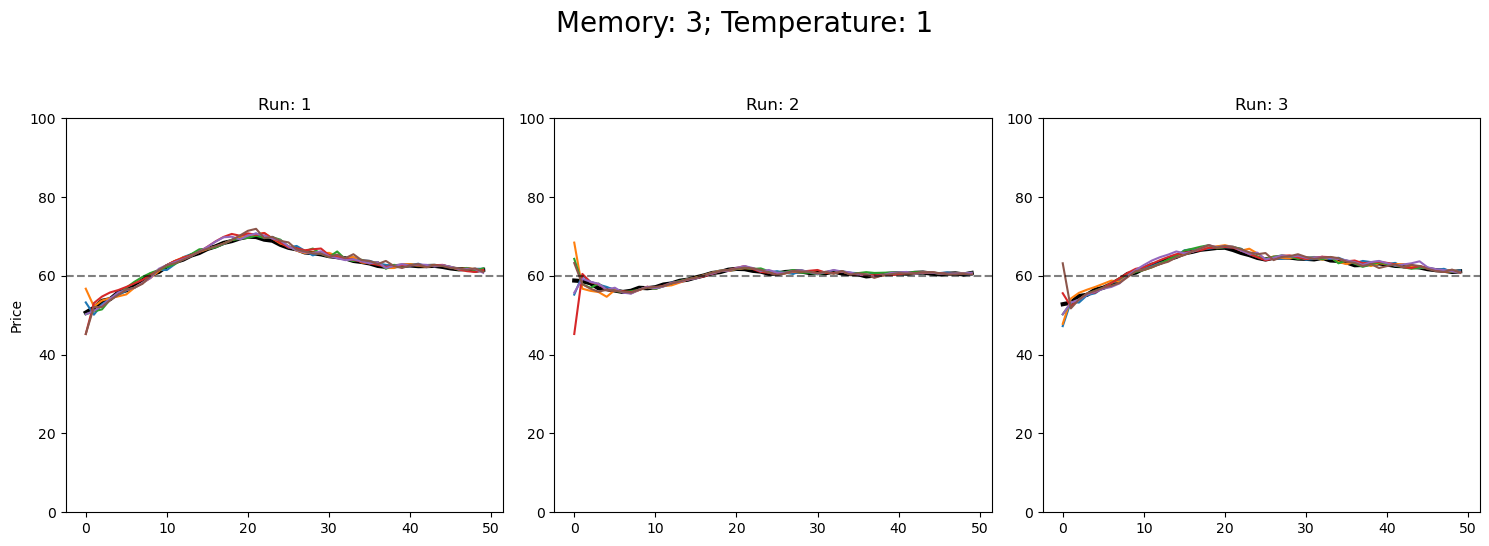

In [15]:
plots_across_runs_and_feedback(['pos'], [1, 2, 3], gpt_model, memory, temperature)

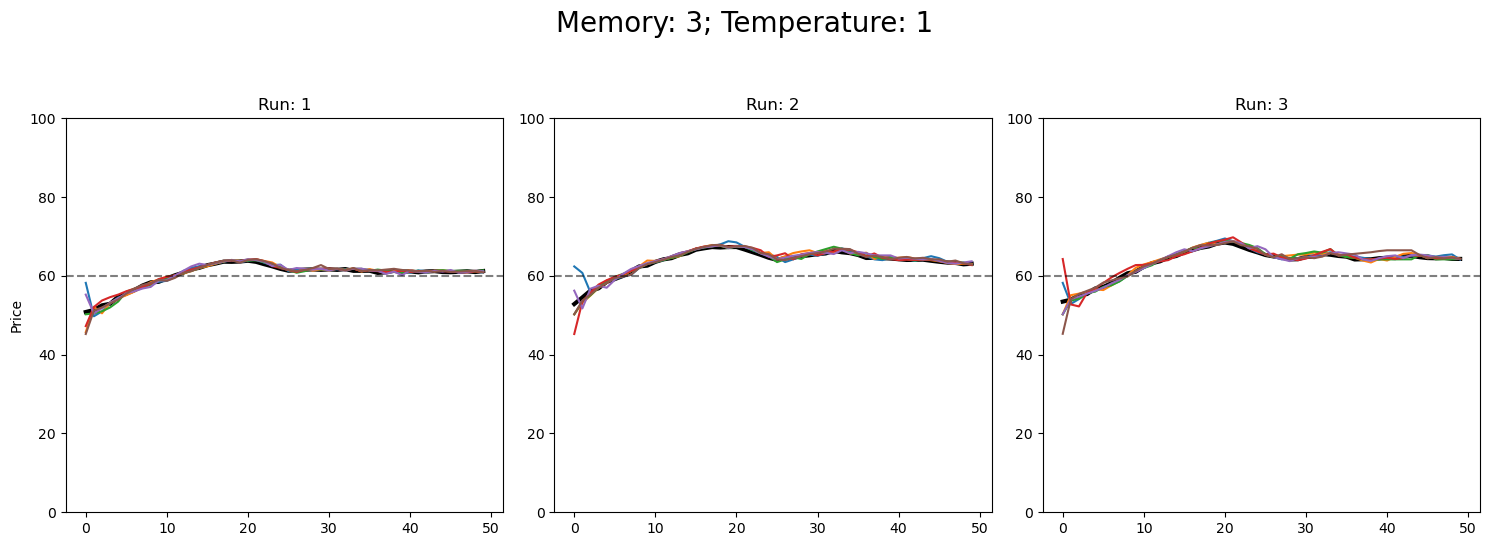

In [16]:
plots_across_runs_and_feedback(['pos'], [4, 5, 6], gpt_model, memory, temperature)

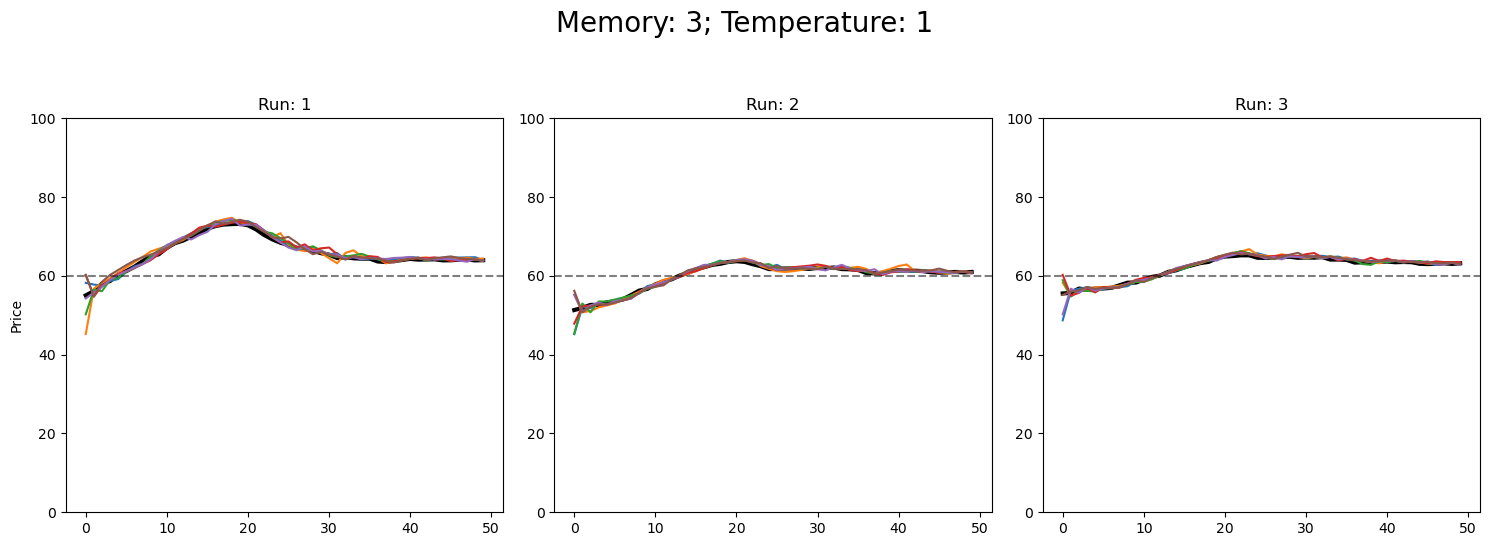

In [18]:
plots_across_runs_and_feedback(['pos'], [7, 8, 9], gpt_model, memory, temperature)

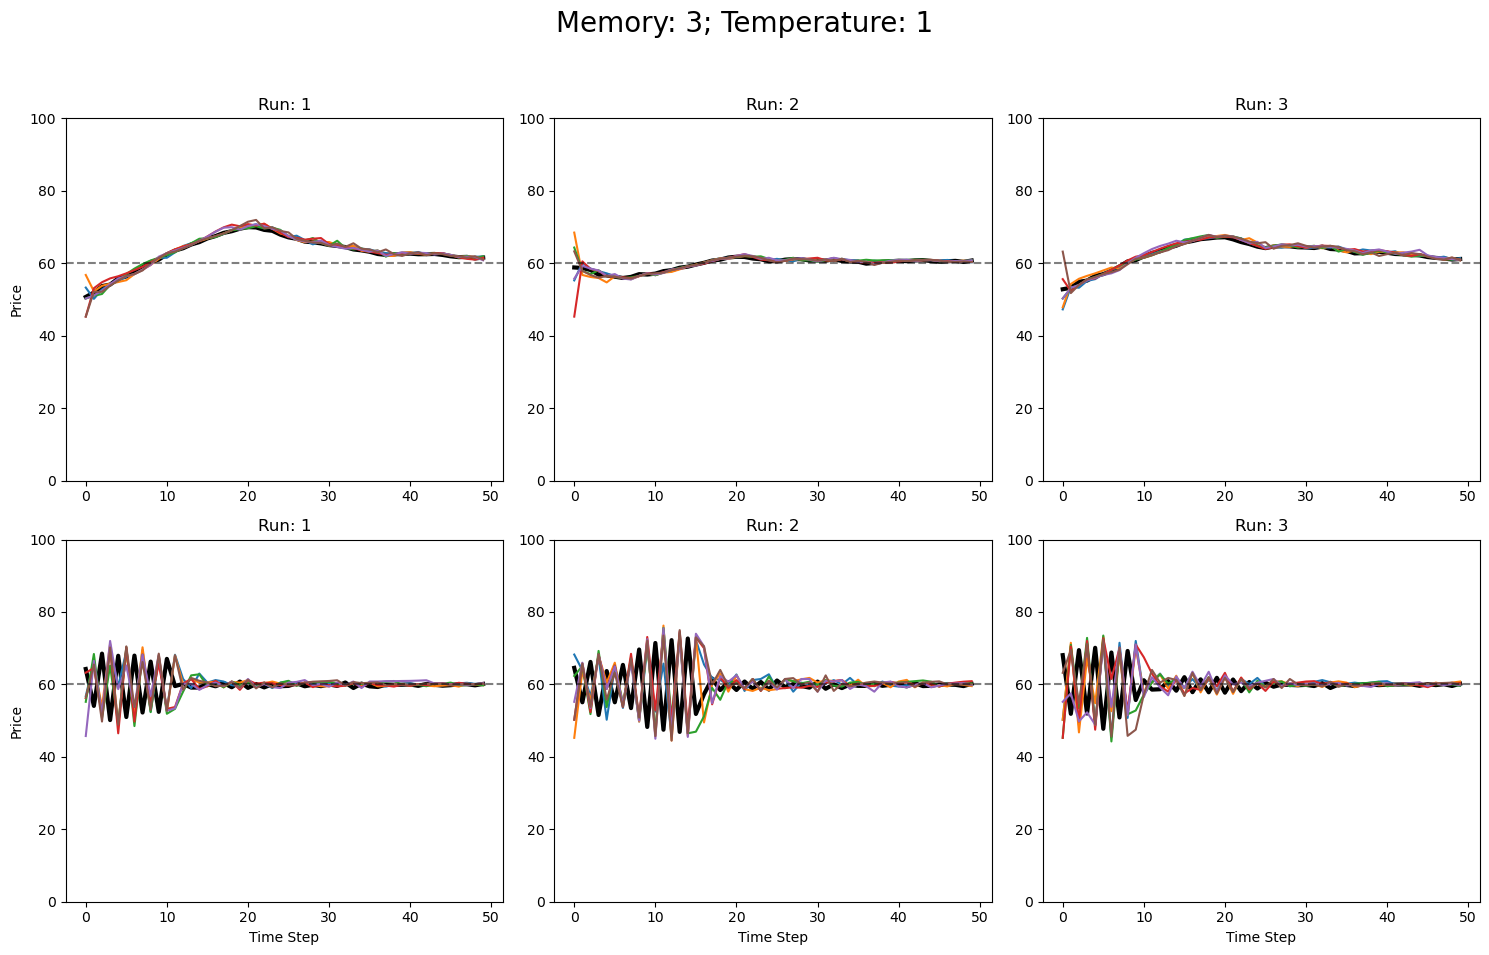

In [13]:
plots_across_runs_and_feedback(['pos', 'neg'], [1, 2, 3], gpt_model, memory, temperature)



# GPT 3 without random

In [8]:
expmnt_nums = [10, 11, 12]
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=False, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the very first time step, I will make a prediction based on historical trends and initial market conditions. I\'ll start with a moderate estimate of 50, considering the typical price range of the product.",\n  "predictedValue": 50\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "I expect the price to be stable at the beginning as demand and supply gradually adjust. I will predict the price to be around the mid-range of possible values, which is 50.",\n  "predictedValue": 50\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the first time step, I will sta

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

def plots_across_runs_and_feedback(feedback_values, expmnt_nums, gpt_model, memory, temperature):
    n = 2  # number of rows (positive and negative feedback)
    m = 3  # number of columns (three runs)

    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(n, m, figure=fig)
    
    max_price_pos = 0
    min_price_pos = 100
    max_price_neg = 0
    min_price_neg = 100
    
    for feedback in feedback_values:
        for expmnt_num in expmnt_nums:
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            if feedback == "pos":
                max_price_pos = max(max_price_pos, df["predicted_price"].max(), df["actual_price"].max())
                min_price_pos = min(min_price_pos, df["predicted_price"].min(), df["actual_price"].min())
    
            if feedback == "neg":
                max_price_neg = max(max_price_neg, df["predicted_price"].max(), df["actual_price"].max())
                min_price_neg = min(min_price_neg, df["predicted_price"].min(), df["actual_price"].min())
    
    for i, feedback in enumerate(feedback_values):
        for j, expmnt_num in enumerate(expmnt_nums):
            ax = fig.add_subplot(gs[i, j])
            try:
                df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6.csv")
            
            except:
                try:
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(temperature).replace('.', '-')}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
                except:
                    
                    df = pd.read_csv(f"../results/experiments/expmnt_results_{feedback}_original_30-50w_num_{expmnt_num}_temp_{str(1)}_memory_{memory}_ntime_50_nagents_6_model_{str(gpt_model).replace('.', '-')}.csv")
            # Plot actual and predicted prices over time_step
            ax.plot(df['time_step'], df['actual_price'], label='Actual Price', color="black", linewidth=3)
            for agent_id, group in df.groupby('agent_id'):
                ax.plot(group['time_step'], group['predicted_price'], label=f'Predicted Price (Agent {agent_id})')
            
            if j == 0:
                ax.set_ylabel('Price')
            if i == 1:
                ax.set_xlabel('Time Step')
            ax.set_title(f"Run: {j+1}")
            ax.axhline(60, linestyle="dashed", color="black", alpha=0.5)
            # if j == 2:
            #     ax.legend(bbox_to_anchor=[1.05, 1])
            if i == 0:
                ax.set_ylim(0, 100)
            if i == 1:
                ax.set_ylim(0, 100)
    
    plt.suptitle(f"Memory: {memory}; Temperature: {temperature}", fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    filename = f"../results/plots/{gpt_model}_memory_{memory}_temperature_{temperature}_alternative_layout_randstart.png"
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

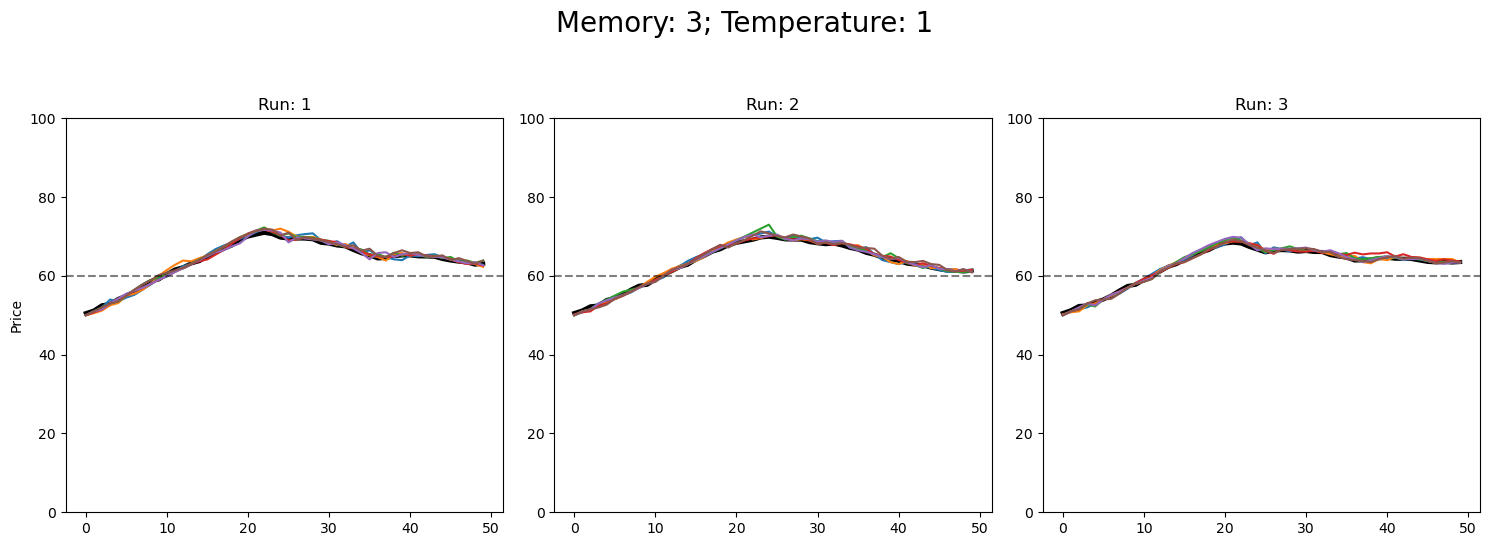

In [11]:
plots_across_runs_and_feedback(['pos'], [10, 11, 12], gpt_model, memory, temperature)

## GPT 4, always give random 50 even when saying random

In [19]:
gpt_model = "gpt-4-1106-preview"

In [ ]:
expmnt_nums = [1, 2, 3]
for expmnt_num in expmnt_nums:
    p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, memory=memory, gpt_model=gpt_model, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, random_start=True, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Without historical data or trends, a conservative random initial price prediction is chosen mid-range to minimize potential error.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "Given no historical market data or trends available, an initial random prediction between 0 and 100 is chosen as a baseline.",\n  "predictedValue": 50.00\n}'}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial random price prediction between 0 and 100.'}
{'role': 'assistant', 'content': '{\n  "reasoning": "As this is the first prediction with no historical data, a median value is a safe initial g

In [ ]:
plots_across_runs_and_feedback(['pos'], [1, 2, 3], gpt_model, memory, temperature)